### Emmaus

# Check what `inclusion=FALSE` means

Find contours in the LIDC XML files that a radiologist marked `inclusion=FALSE`, and show what they do to a nodule.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Rectangle

# the notebook runs from xml_preprocessing/, so point Python at pipeline/ to import ct.py
sys.path.insert(0, str(Path.cwd().parent / "pipeline"))
from ct import load_slice_index, read_hu, slice_path, to_uint8_window

Z_MATCH_MM = 0.1 # a contour's z must be this close to a real slice
slices = load_slice_index()

## What `inclusion=FALSE` means

Each `<roi>` in an XML file is one contour a radiologist drew on one slice. `<inclusion>TRUE</inclusion>` means the contour is the edge of the nodule: everything inside it is nodule. `<inclusion>FALSE</inclusion>` means the contour marks a region an exclusion of the nodule on that slice, such as an air-filled hole in a cavitary nodule.

This code searches every XML file for `inclusion=FALSE` contours and lists them, biggest hole first.

In [ ]:
import xml.etree.ElementTree as ET

XML_DIR = Path("/Volumes/Expansion/LIDC-XML/tcia-lidc-xml")

ct_series = set(slices["series_instance_uid"]) # skip the chest X-ray XMLs
uid_to_patient = slices.drop_duplicates("series_instance_uid").set_index("series_instance_uid")["patient_id"]

def contour_box(roi, ns):
    """The outermost x and y pixels of one contour."""
    xs = [int(p.find("lidc:xCoord", ns).text) for p in roi.findall("lidc:edgeMap", ns)]
    ys = [int(p.find("lidc:yCoord", ns).text) for p in roi.findall("lidc:edgeMap", ns)]
    return min(xs), max(xs), min(ys), max(ys)

exclusions = []
n_true = n_false = 0
for xml_file in sorted(p for p in XML_DIR.glob("*/*.xml") if not p.name.startswith(".")):
    root = ET.parse(xml_file).getroot()
    ns = {"lidc": root.tag.split("}")[0].strip("{")}
    uid_tag = root.find(".//lidc:SeriesInstanceUid", ns)
    if uid_tag is None or uid_tag.text.strip() not in ct_series:
        continue
    uid = uid_tag.text.strip()
    for reader, session in enumerate(root.findall(".//lidc:readingSession", ns)):
        for nodule in session.findall("lidc:unblindedReadNodule", ns):
            nodule_id = nodule.find("lidc:noduleID", ns).text.strip()
            rois = nodule.findall("lidc:roi", ns)
            inclusion_flags = [r.find("lidc:inclusion", ns).text.strip().upper() == "TRUE" for r in rois]
            n_true += sum(inclusion_flags)
            n_false += len(inclusion_flags) - sum(inclusion_flags)
            for roi, is_inclusion in zip(rois, inclusion_flags):
                if is_inclusion:
                    continue
                z = float(roi.find("lidc:imageZposition", ns).text)
                hole_x_min, hole_x_max, hole_y_min, hole_y_max = contour_box(roi, ns)
                # Find the contour with inclusion set to true that is on the same slice
                for other, other_is_inclusion in zip(rois, inclusion_flags):
                    if not other_is_inclusion or abs(float(other.find("lidc:imageZposition", ns).text) - z) > Z_MATCH_MM:
                        continue
                    outline_x_min, outline_x_max, outline_y_min, outline_y_max = contour_box(other, ns)
                    inside = (outline_x_min < hole_x_min and hole_x_max < outline_x_max
                              and outline_y_min < hole_y_min and hole_y_max < outline_y_max)
                    if inside:
                        exclusions.append({"patient_id": uid_to_patient[uid], "xml_file": str(xml_file),
                                           "reader": reader, "nodule_id": nodule_id, "z_slice": z,
                                           "hole_px": (hole_x_max - hole_x_min + 1) * (hole_y_max - hole_y_min + 1),
                                           "outline_px": (outline_x_max - outline_x_min + 1) * (outline_y_max - outline_y_min + 1)})
                        break

# biggest holes first: they show most clearly what an exclusion is
candidates = pd.DataFrame(exclusions).sort_values("hole_px", ascending=False).reset_index(drop=True)
print(f"contours in CT XMLs: {n_true} inclusion=TRUE, {n_false} inclusion=FALSE ({n_false / (n_true + n_false):.1%})")
print(f"inclusion=FALSE contours inside a TRUE contour on the same slice: {len(candidates)} of {n_false}")
candidates.head(10)


contours in CT XMLs: 54462 inclusion=TRUE, 1013 inclusion=FALSE (1.8%)
inclusion=FALSE contours inside a TRUE contour on the same slice: 971 of 1013


,patient_id,xml_file,reader,nodule_id,z_slice,hole_px,outline_px
0,LIDC-IDRI-0186,/Volumes/Expansion/LIDC-XML/tcia-lidc-xml/186/...,2,135154,-65.000000,399,1591
1,LIDC-IDRI-0072,/Volumes/Expansion/LIDC-XML/tcia-lidc-xml/185/...,1,101448,-55.000000,378,1287
2,LIDC-IDRI-0072,/Volumes/Expansion/LIDC-XML/tcia-lidc-xml/185/...,1,101448,-53.750000,336,1209
3,LIDC-IDRI-0072,/Volumes/Expansion/LIDC-XML/tcia-lidc-xml/185/...,1,101448,-52.500000,320,957
4,LIDC-IDRI-0072,/Volumes/Expansion/LIDC-XML/tcia-lidc-xml/185/...,1,101448,-51.250000,304,986
5,LIDC-IDRI-0072,/Volumes/Expansion/LIDC-XML/tcia-lidc-xml/185/...,1,101448,-56.250000,294,1520
6,LIDC-IDRI-0194,/Volumes/Expansion/LIDC-XML/tcia-lidc-xml/186/...,2,160373,-214.500000,272,1862
7,LIDC-IDRI-0332,/Volumes/Expansion/LIDC-XML/tcia-lidc-xml/187/...,1,5022,-141.584991,260,3100
8,LIDC-IDRI-0332,/Volumes/Expansion/LIDC-XML/tcia-lidc-xml/187/...,1,5022,-149.584991,240,3055
9,LIDC-IDRI-0072,/Volumes/Expansion/LIDC-XML/tcia-lidc-xml/185/...,1,101448,-57.500000,216,1620


This code draws one of nodules.

`EXAMPLE = 0` is the biggest, a cavitary nodule in LIDC-IDRI-0186 whose air-filled hole one reader drew as an exclusion. The bounding box only comes from ROIs with `inclusion=TRUE` because an exclusion always sits inside the nodule's outline, so it doesn't affect the box. As such, `xml_preprocessing_bb_a.py` skips `inclusion=FALSE` contours.

127.xml, reader 2, nodule 135154, z = -65.0 mm: 1 inclusion=TRUE, 1 inclusion=FALSE contour(s)
nodule area ignoring the exclusion: 475 mm^2 | with the exclusion cut out: 357 mm^2


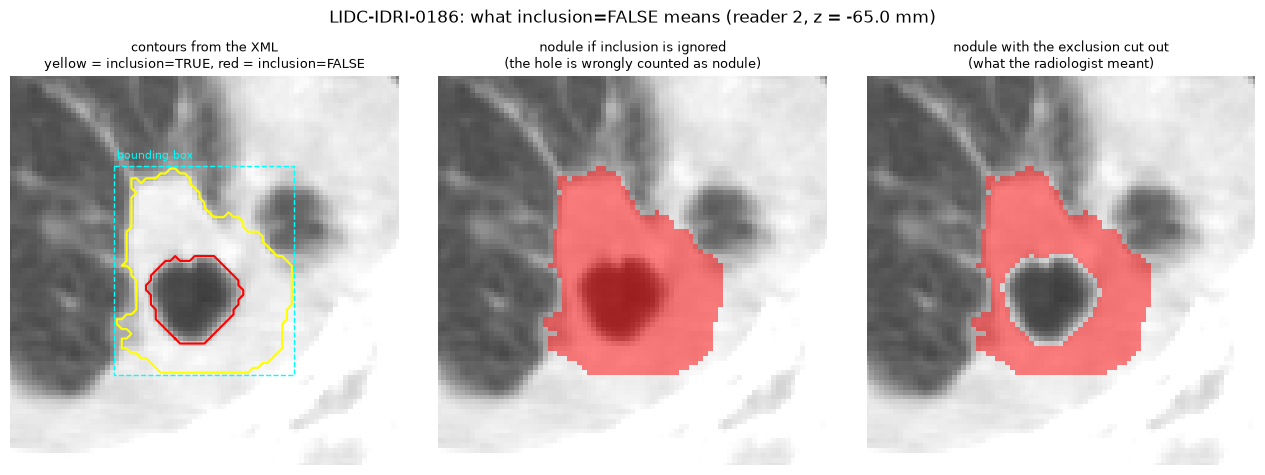

In [ ]:
import numpy as np
from matplotlib.colors import ListedColormap
from skimage.draw import polygon2mask

from ct import load_series_index

EXAMPLE_ROW = 0 # which row of `candidates` (from the cell above) to show; 0 = the biggest hole
example = candidates.iloc[EXAMPLE_ROW]
XML_PATH = Path(example["xml_file"])
READER = example["reader"] # which <readingSession> in the file, starts from 0
NODULE_ID = example["nodule_id"]
Z_SLICE = example["z_slice"]
ZOOM_WIDTH_PX = 80 # None means whole 512x512 px slice

# Read reader's contours for this slice directly from the XML
root = ET.parse(XML_PATH).getroot()
ns = {"lidc": root.tag.split("}")[0].strip("{")}
uid = root.find(".//lidc:SeriesInstanceUid", ns).text.strip()
session = root.findall(".//lidc:readingSession", ns)[READER]
nodule = next(n for n in session.findall("lidc:unblindedReadNodule", ns)
              if n.find("lidc:noduleID", ns).text.strip() == NODULE_ID)

contours = [] # (inclusion, xs, ys) for every roi on Z_SLICE
for roi in nodule.findall("lidc:roi", ns):
    if abs(float(roi.find("lidc:imageZposition", ns).text) - Z_SLICE) > Z_MATCH_MM:
        continue
    inclusion = roi.find("lidc:inclusion", ns).text.strip().upper() == "TRUE"
    xs = [int(p.find("lidc:xCoord", ns).text) for p in roi.findall("lidc:edgeMap", ns)]
    ys = [int(p.find("lidc:yCoord", ns).text) for p in roi.findall("lidc:edgeMap", ns)]
    contours.append((inclusion, xs, ys))
print(f"{XML_PATH.name}, reader {READER}, nodule {NODULE_ID}, z = {Z_SLICE} mm: "
      f"{sum(c[0] for c in contours)} inclusion=TRUE, {sum(not c[0] for c in contours)} inclusion=FALSE contour(s)")

# Get the ct slice
series_slices = slices[slices["series_instance_uid"] == uid] # slices is from load_slice_index()
nearest = series_slices.iloc[(series_slices["z"] - Z_SLICE).abs().argmin()]
patient_id = nearest["patient_id"]
hu = read_hu(slice_path(patient_id, uid, int(nearest["idx"])))
image = to_uint8_window(hu)

# True adds to the mask, false cuts a hole out of the mask
def contour_to_mask(xs, ys):
    return polygon2mask(hu.shape, np.column_stack([ys, xs])) # wants (row, col) points

inclusion_mask = np.zeros(hu.shape, dtype=bool)
exclusion_mask = np.zeros(hu.shape, dtype=bool)
for inclusion, xs, ys in contours:
    if inclusion:
        inclusion_mask |= contour_to_mask(xs, ys) # |= is or but it's an operator
    else:
        exclusion_mask |= contour_to_mask(xs, ys)
nodule_ignoring_false = inclusion_mask # what you'd get if you ignored <inclusion>
nodule_correct = inclusion_mask & ~exclusion_mask # what the radiologist meant

pixel_area_mm2 = load_series_index().loc[uid, "row_spacing"] * load_series_index().loc[uid, "col_spacing"]
print(f"nodule area ignoring the exclusion: {nodule_ignoring_false.sum() * pixel_area_mm2:.0f} mm^2 | "
      f"with the exclusion cut out: {nodule_correct.sum() * pixel_area_mm2:.0f} mm^2")

# Show a bounding box to show that it is safe to skip inclusion=FALSE ROIs
inclusion_xs = [x for is_inclusion, xs, _ in contours if is_inclusion for x in xs]
inclusion_ys = [y for is_inclusion, _, ys in contours if is_inclusion for y in ys]
x_min, x_max, y_min, y_max = min(inclusion_xs), max(inclusion_xs), min(inclusion_ys), max(inclusion_ys)
cx, cy = (x_min + x_max) / 2, (y_min + y_max) / 2

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8))
titles = ["contours from the XML\nyellow = inclusion=TRUE, red = inclusion=FALSE",
          "nodule if inclusion is ignored\n(the hole is wrongly counted as nodule)",
          "nodule with the exclusion cut out\n(what the radiologist meant)"]
for ax, title in zip(axes, titles):
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    if ZOOM_WIDTH_PX is not None:
        half = ZOOM_WIDTH_PX / 2
        ax.set_xlim(cx - half, cx + half)
        ax.set_ylim(cy + half, cy - half) # bigger row number first: image rows count downwards
    ax.axis("off")

for inclusion, xs, ys in contours: # Close each outline by returning to its first point
    axes[0].plot(xs + xs[:1], ys + ys[:1], color="yellow" if inclusion else "red", linewidth=1.5)
axes[0].add_patch(Rectangle((x_min - 0.5, y_min - 0.5), x_max - x_min + 1, y_max - y_min + 1,
                            edgecolor="cyan", facecolor="none", linewidth=1, linestyle="--"))
axes[0].text(x_min, y_min - 2, "bounding box", color="cyan", fontsize=8)

for ax, mask in ((axes[1], nodule_ignoring_false), (axes[2], nodule_correct)):
    ax.imshow(np.ma.masked_where(~mask, mask), cmap=ListedColormap(["red"]), alpha=0.5)   # red = counted as nodule

fig.suptitle(f"{patient_id}: what inclusion=FALSE means (reader {READER}, z = {Z_SLICE} mm)", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()
